In [903]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
from random import sample 
import copy
import h5py
import matplotlib

In [154]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [155]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [156]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [157]:
def save_halo_sel(sel_mask, vmax_sel=False, Nhalos=None):

    idx = []
    if vmax_sel is True:
        for m in range(len(sel_mask['vmax_Custom']['h_idx'])):
            for v in range(len(sel_mask['vmax_Custom']['h_idx'][m])):
                idx.extend(sel_mask['vmax_Custom']['h_idx'][m][v])

        idx = np.unique(np.array(idx))

        with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/vmax_custom_sel.txt".format(Nhalos), 'w') as f:
            for i in range(len(idx)):
                if i==len(idx)-1:
                    f.write(str(idx[i]))
                else:
                    f.write(str(idx[i])+'\n')

    else:
        idx = sel_mask['Custom']['h_idx']

        np.save("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/regular_selection".format(Nhalos), [idx])

    return 1


In [158]:
basedir = "/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/"

resolution_level = 1

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME
numpart = int(1080**3*2**(3-3*resolution_level))

mtng_dm = bacco.Simulation(basedir=basedir, halo_file="groups_264/fof_subhalo_tab_264", sim_format='TNG500', fixedPk=True, sigma8=sigma8,\
    tau=tau, ns=ns, numpart=numpart, use_orphans=False)

2024-07-16 10:52:31,246 bacco.sims : Initialising simulation Default
2024-07-16 10:52:31,247 bacco.sims : try /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/groups_264/fof_subhalo_tab_264
2024-07-16 10:52:31,249 bacco.sims : Loading /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/groups_264/fof_subhalo_tab_264
2024-07-16 10:52:31,255 bacco.sims : ...done in 0.00686 s


In [159]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)

2024-07-16 10:52:31,293 bacco.sims : Initialising simulation Default
2024-07-16 10:52:31,294 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-16 10:52:31,296 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-16 10:52:31,299 bacco.sims : Creating snapshot array from /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264 because: exists=True, newer=False
/lscratch/fgmaion/baccogit/bacco/simulation.py:1386: UserWarning: loadtxt: input contained no data: "/cosmos_storage/simulations/MTNG//snaplist.txt"
  tab = np.loadtxt(self.BaseDir + '/snaplist.txt')
2024-07-16 10:52:31,314 bacco.sims : Warning: Empty snaplist.txt
2024-07-16 10:52:31,315 bacco.sims : ...done in 0.00564 s


In [160]:
Nbins = 30
hydro_split = utils.split_halos(mtng)

### Define ranges of halo mass

In [562]:
mbins = np.concatenate(
    (np.arange(10, 12.5, 0.05),
    np.arange(12.5, 13.5, 0.1),
    np.arange(13.5, 15.5001, 0.5))
)

In [563]:
mass_edges = np.array(list(zip(mbins[:-1], mbins[1:])))

### Plot their Mass and Concentration

In [553]:
m200b = 1e10 * mtng.fof['halo_m200b']
M_T = np.sum(m200b)

presel = np.where(m200b>10**mass_edges[0,0])

m200b = m200b[presel]

In [542]:
halo_vmax = mtng.sub['vmax'][mtng.fof['halo_firstsub']][presel]
r200b = mtng.fof['halo_r200b'][presel]
G_newton = 4.3009172706e-9 #Mpc/M_sun * (km/s)**2
halo_v200 = np.sqrt(G_newton*m200b/r200b)
vmax_v200 = halo_vmax / halo_v200

In [347]:
sel_total = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=None)

In [697]:
ens_sel = {}

ens_sel['2'] = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=2, draws=100)
ens_sel['4'] = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=4, draws=100)

0.5216782093048096
0.5218496322631836
50.82833814620972
0.5478348731994629
0.5480310916900635
55.04609417915344


In [740]:
ens_sel_vmax = {}

ens_sel_vmax['2'] = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=2, vmax_sel=True, draws=100)
ens_sel_vmax['4'] = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=4, vmax_sel=True, draws=100)

0.5429518222808838
65.59447026252747
0.5435459613800049
79.44833707809448


### Visualize our selection

Compute their mass-fractions

In [699]:
mfrac = {}
mfrac['2'] = np.zeros(100)
mfrac['4'] = np.zeros(100)

for d in range(100):
    for m in range(mass_edges.shape[0]):
        mfrac['2'][d] += np.sum(m200b[ens_sel['2']['sel'][m][d]]) / M_T
        mfrac['4'][d] += np.sum(m200b[ens_sel['4']['sel'][m][d]]) / M_T

In [741]:
mfrac_vmax = {}
mfrac_vmax['2'] = np.zeros(100)
mfrac_vmax['4'] = np.zeros(100)

for d in range(100):
    for m in range(mass_edges.shape[0]):
        mfrac_vmax['2'][d] += np.sum(m200b[ens_sel_vmax['2']['sel'][m][d]]) / M_T
        mfrac_vmax['4'][d] += np.sum(m200b[ens_sel_vmax['4']['sel'][m][d]]) / M_T

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


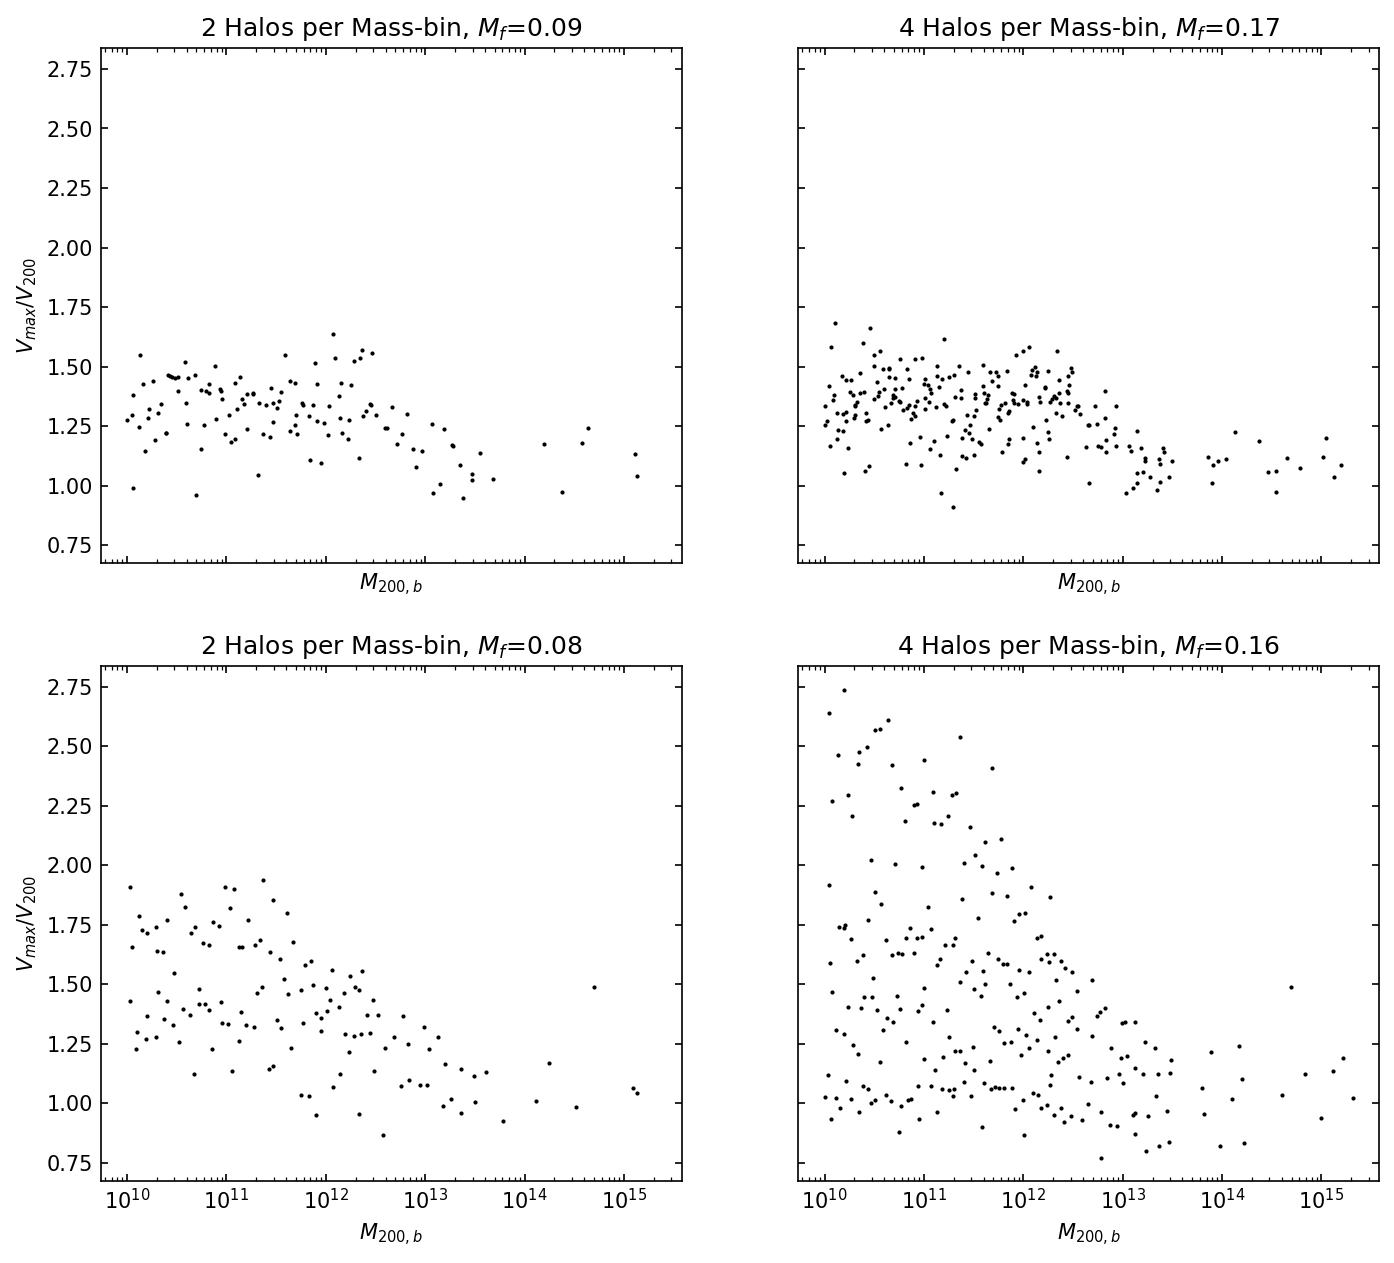

In [591]:
fig, ax = plt.subplots(2,2,dpi=150, figsize=(11,10), sharey=True, sharex=True)

ax[0,0].set_xscale('log')
#ax[0].set_yscale('log')

ax[0,0].set_xlabel('$M_{200,b}$')
ax[0,0].set_ylabel('$V_{max}/V_{200}$')

ax[0,0].set_title('2 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac['2'])))

for m in range(mass_edges.shape[0]):
    ax[0,0].plot(m200b[ens_sel[0]['2']['sel'][m]], vmax_v200[ens_sel[0]['2']['sel'][m]], marker='o', ls='', color='k', ms=1)

ax[0,0].legend(loc='upper left')

ax[0,1].set_xscale('log')
#ax[1].set_yscale('log')

ax[0,1].set_xlabel('$M_{200,b}$')

ax[0,1].set_title('4 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac['4'])))

cmap = matplotlib.cm.get_cmap('viridis')

for m in range(mass_edges.shape[0]):
    ax[0,1].plot(m200b[ens_sel[0]['4']['sel'][m]], vmax_v200[ens_sel[0]['4']['sel'][m]], marker='o', ls='', color='k', ms=1)

ax[0,1].legend(loc='upper left')

ax[1,0].set_xscale('log')
#ax[0].set_yscale('log')

ax[1,0].set_xlabel('$M_{200,b}$')
ax[1,0].set_ylabel('$V_{max}/V_{200}$')

ax[1,0].set_title('2 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac_vmax['2'])))

for m in range(mass_edges.shape[0]):
    ax[1,0].plot(m200b[ens_sel_vmax[0]['2']['sel'][m]], vmax_v200[ens_sel_vmax[0]['2']['sel'][m]], marker='o', ls='', color='k', ms=1)

ax[1,0].legend(loc='upper left')

ax[1,1].set_xscale('log')
#ax[1].set_yscale('log')

ax[1,1].set_xlabel('$M_{200,b}$')

ax[1,1].set_title('4 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac_vmax['4'])))

cmap = matplotlib.cm.get_cmap('viridis')

for m in range(mass_edges.shape[0]):
    ax[1,1].plot(m200b[ens_sel_vmax[0]['4']['sel'][m]], vmax_v200[ens_sel_vmax[0]['4']['sel'][m]], marker='o', ls='', color='k', ms=1)

ax[1,1].legend(loc='upper left')

### SMF for these selections

In [36]:
nbins=30

In [751]:
ens_smf = {}
ens_smf['2'] = np.zeros((100, nbins-1))
ens_smf['4'] = np.zeros((100, nbins-1))

ens_mstar = {}
ens_mstar['2'] = np.zeros((100, nbins-1))
ens_mstar['4'] = np.zeros((100, nbins-1))

temp_4 = hydro_split.halo_smf(sel_mask=ens_sel['4'], nbins=nbins, mhalo_edges=mass_edges, draws=100)
temp_2 = hydro_split.halo_smf(sel_mask=ens_sel['2'], nbins=nbins, mhalo_edges=mass_edges, draws=100)

for i in range(100):
    ens_smf['2'][i] = temp_2['smf'][i]
    ens_mstar['2'][i] = temp_2['mstar'][i]
    ens_mstar['2'][i][np.where(np.isnan(ens_mstar['2'][i]))] = 0

    ens_smf['4'][i] = temp_4['smf'][i]
    ens_mstar['4'][i] = temp_4['mstar'][i]
    ens_mstar['4'][i][np.where(np.isnan(ens_mstar['4'][i]))] = 0


/lscratch/fgmaion/MTNG-resims/src/utils.py:210: RuntimeWarning: invalid value encountered in divide
  


In [752]:
mean_smf = {}
mean_smf['2'] = np.mean(ens_smf['2'], axis=0)
mean_smf['4'] = np.mean(ens_smf['4'], axis=0)

mean_mstar = {}
mean_mstar['2'] = np.mean(ens_mstar['2'], axis=0)
mean_mstar['4'] = np.mean(ens_mstar['4'], axis=0)

err_smf = {}
err_smf['2'] = np.std(ens_smf['2'], axis=0)
err_smf['4'] = np.std(ens_smf['4'], axis=0)

In [845]:
ens_smf_vmax = {}
ens_smf_vmax['2'] = np.zeros((100, nbins-1))
ens_smf_vmax['4'] = np.zeros((100, nbins-1))

ens_mstar_vmax = {}
ens_mstar_vmax['2'] = np.zeros((100, nbins-1))
ens_mstar_vmax['4'] = np.zeros((100, nbins-1))

temp_4 = hydro_split.halo_smf(sel_mask=ens_sel_vmax['4'], nbins=nbins, mhalo_edges=mass_edges, vmax_sel=True, draws=100)
temp_2 = hydro_split.halo_smf(sel_mask=ens_sel_vmax['2'], nbins=nbins, mhalo_edges=mass_edges, vmax_sel=True, draws=100)

for i in range(100):
    ens_smf_vmax['2'][i] = temp_2['smf'][i]
    ens_mstar_vmax['2'][i] = temp_2['mstar'][i]
    ens_mstar_vmax['2'][i][np.where(np.isnan(ens_mstar_vmax['2'][i]))] = 0

    ens_smf_vmax['4'][i] = temp_4['smf'][i]
    ens_mstar_vmax['4'][i] = temp_4['mstar'][i]
    ens_mstar_vmax['4'][i][np.where(np.isnan(ens_mstar_vmax['4'][i]))] = 0


IndexError: list index out of range

In [761]:
mean_smf_vmax = {}
mean_smf_vmax['2'] = np.mean(ens_smf_vmax['2'], axis=0)
mean_smf_vmax['4'] = np.mean(ens_smf_vmax['4'], axis=0)

mean_mstar_vmax = {}
mean_mstar_vmax['2'] = np.mean(ens_mstar_vmax['2'], axis=0)
mean_mstar_vmax['4'] = np.mean(ens_mstar_vmax['4'], axis=0)

err_smf_vmax = {}
err_smf_vmax['2'] = np.std(ens_smf_vmax['2'], axis=0)
err_smf_vmax['4'] = np.std(ens_smf_vmax['4'], axis=0)

In [249]:
smf_total = hydro_split.total_smf(nbins=nbins)

In [613]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

In [614]:
GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = 10**GAMA[:,0] / 0.7**2
GAMA_corr[:,1] = 10**GAMA[:,1] * 0.7**3

GAMA_corr[:,2] = 10**GAMA[:,1] - 10**(GAMA[:,1] - GAMA[:,2])
GAMA_corr[:,3] = 10**(GAMA[:,1] + GAMA[:,2]) - 10**GAMA[:,1]

In [419]:
hist_total, bins_total = np.histogram(np.log10(1e10*mtng.sub['MassType'][:,4]), bins=np.linspace(8,13,30))

/tmp/ipykernel_285604/4185638414.py:1: RuntimeWarning: divide by zero encountered in log10
  hist_total, bins_total = np.histogram(np.log10(1e10*mtng.sub['MassType'][:,4]), bins=np.linspace(8,13,30))


In [420]:
centers_total = 0.5 * (bins_total[1:] + bins_total[:-1])

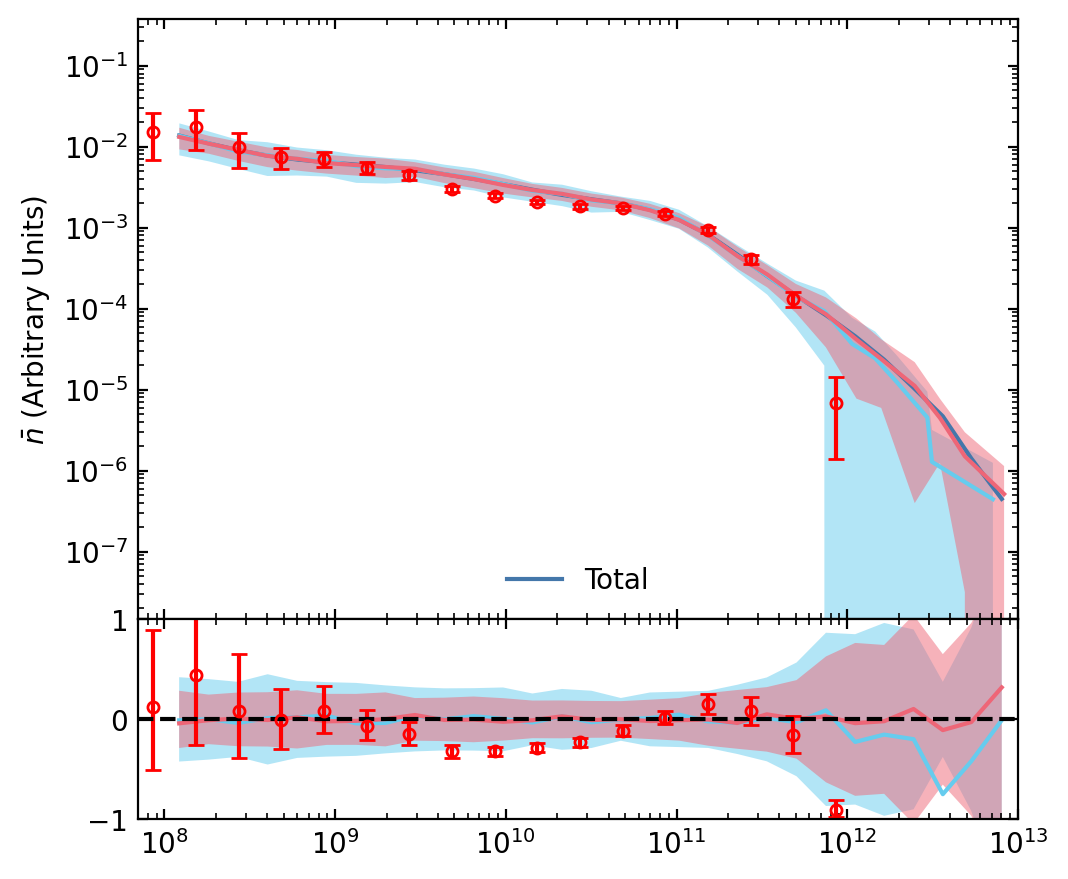

In [727]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xlim(7e7,1e13)

ax1.plot(smf_total['mstar'], smf_total['smf'], label='Total', color=colors[0])
ax1.plot(mean_mstar['2'], mean_smf['2'], color=colors[1]) 
ax1.plot(mean_mstar['4'], mean_smf['4'], color=colors[4]) 

ax1.fill_between(mean_mstar['2'], mean_smf['2']-err_smf['2'], mean_smf['2']+err_smf['2'], color=colors[1], alpha=0.5, edgecolor=None)
ax1.fill_between(mean_mstar['4'], mean_smf['4']-err_smf['4'], mean_smf['4']+err_smf['4'], color=colors[4], alpha=0.5, edgecolor=None)

#ax1.hist(centers_total, bins=bins_total, weights=1.56e-8*hist_total, log=True, histtype='step')

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower center')

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xlim(7e7,1e13)

ax2.set_xscale('log')

ax2.plot(smf_total['mstar'], np.interp(smf_total['mstar'], mean_mstar['2'], mean_smf['2'])/smf_total['smf'] - 1, color=colors[1])
ax2.plot(smf_total['mstar'], np.interp(smf_total['mstar'], mean_mstar['4'], mean_smf['4'])/smf_total['smf'] - 1, color=colors[4])

ax2.fill_between(smf_total['mstar'], -np.interp(smf_total['mstar'], mean_mstar['2'], err_smf['2'])/smf_total['smf'], np.interp(smf_total['mstar'], mean_mstar['2'], err_smf['2'])/smf_total['smf'], color=colors[1], alpha=0.5, edgecolor=None)
ax2.fill_between(smf_total['mstar'], -np.interp(smf_total['mstar'], mean_mstar['4'], err_smf['4'])/smf_total['smf'], np.interp(smf_total['mstar'], mean_mstar['4'], err_smf['4'])/smf_total['smf'], color=colors[4], alpha=0.5, edgecolor=None)

ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']) - 1, yerr=[GAMA_corr[:,2], GAMA_corr[:,3]]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']),\
 marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_ylim(-1,1)
ax2.axhline(0, ls='--', color='k')

# ax2.set_ylim(-0.5,0.5)

# #ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
# #ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

# ax2.set_ylabel('$\log_{10}(\\bar{n}/\\bar{n}_T)$')
# ax2.set_xlabel('$M_*[M_{\odot}/h]$')


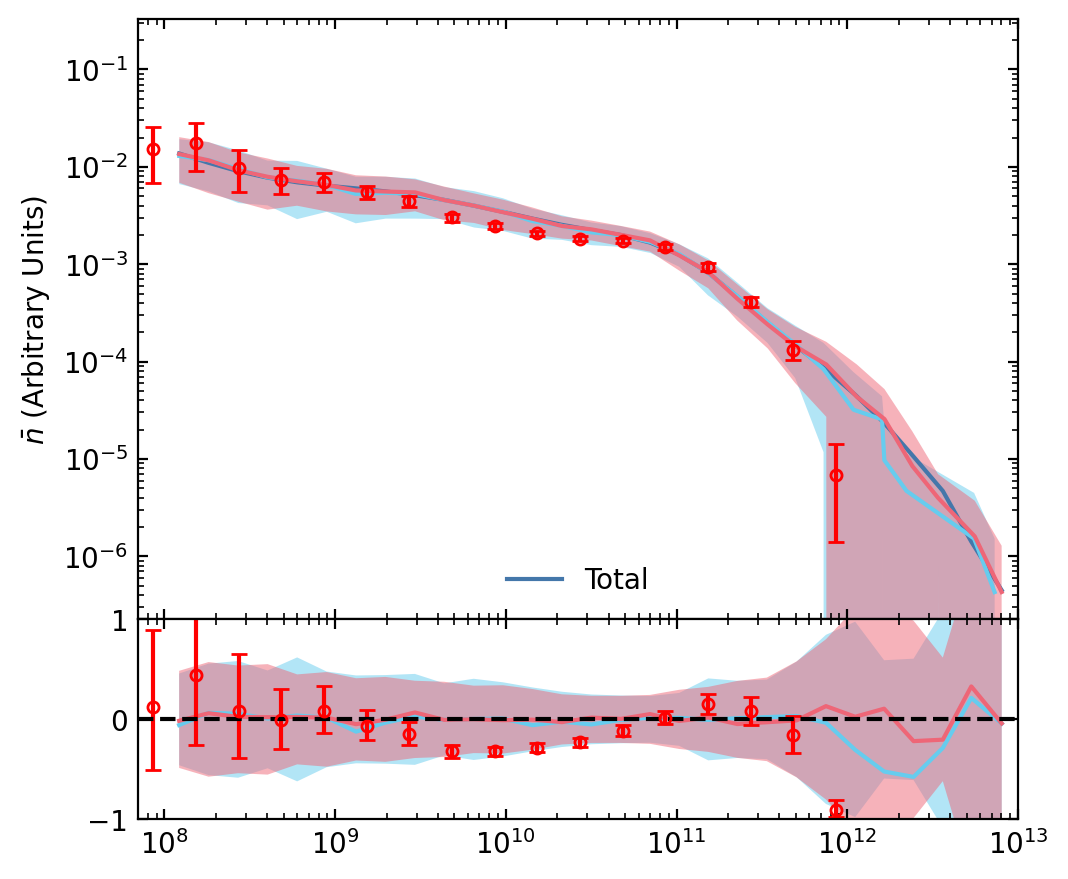

In [762]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xlim(7e7,1e13)

ax1.plot(smf_total['mstar'], smf_total['smf'], label='Total', color=colors[0])
ax1.plot(mean_mstar_vmax['2'], mean_smf_vmax['2'], color=colors[1]) 
ax1.plot(mean_mstar_vmax['4'], mean_smf_vmax['4'], color=colors[4]) 

ax1.fill_between(mean_mstar_vmax['2'], mean_smf_vmax['2']-err_smf_vmax['2'], mean_smf_vmax['2']+err_smf_vmax['2'], color=colors[1], alpha=0.5, edgecolor=None)
ax1.fill_between(mean_mstar_vmax['4'], mean_smf_vmax['4']-err_smf_vmax['4'], mean_smf_vmax['4']+err_smf_vmax['4'], color=colors[4], alpha=0.5, edgecolor=None)

#ax1.hist(centers_total, bins=bins_total, weights=1.56e-8*hist_total, log=True, histtype='step')

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower center')

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xlim(7e7,1e13)

ax2.set_xscale('log')

ax2.plot(smf_total['mstar'], np.interp(smf_total['mstar'], mean_mstar_vmax['2'], mean_smf_vmax['2'])/smf_total['smf'] - 1, color=colors[1])
ax2.plot(smf_total['mstar'], np.interp(smf_total['mstar'], mean_mstar_vmax['4'], mean_smf_vmax['4'])/smf_total['smf'] - 1, color=colors[4])

ax2.fill_between(smf_total['mstar'], -np.interp(smf_total['mstar'], mean_mstar_vmax['2'], err_smf_vmax['2'])/smf_total['smf'], np.interp(smf_total['mstar'], mean_mstar_vmax['2'], err_smf_vmax['2'])/smf_total['smf'], color=colors[1], alpha=0.5, edgecolor=None)
ax2.fill_between(smf_total['mstar'], -np.interp(smf_total['mstar'], mean_mstar_vmax['4'], err_smf_vmax['4'])/smf_total['smf'], np.interp(smf_total['mstar'], mean_mstar_vmax['4'], err_smf_vmax['4'])/smf_total['smf'], color=colors[4], alpha=0.5, edgecolor=None)

ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']) - 1, yerr=[GAMA_corr[:,2], GAMA_corr[:,3]]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']),\
 marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_ylim(-1,1)
ax2.axhline(0, ls='--', color='k')

# ax2.set_ylim(-0.5,0.5)

# #ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
# #ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

# ax2.set_ylabel('$\log_{10}(\\bar{n}/\\bar{n}_T)$')
# ax2.set_xlabel('$M_*[M_{\odot}/h]$')


## What about gas-fraction

In [643]:
m500_bins = np.arange(10, 15, 0.1)
m500_edges = np.array(list(zip(m500_bins[:-1], m500_bins[1:])))

In [878]:
nbins=11

ens_fgas = {}
ens_fgas['2'] = np.zeros((100, nbins-1))
ens_fgas['4'] = np.zeros((100, nbins-1))

ens_m500 = {}
ens_m500['2'] = np.zeros((100, nbins-1))
ens_m500['4'] = np.zeros((100, nbins-1))

temp_4 = hydro_split.halo_gas_frac(mhalo_edges=mass_edges, sel_mask=ens_sel['4'], vmax_sel=False, nbins=nbins, draws=100)
temp_2 = hydro_split.halo_gas_frac(mhalo_edges=mass_edges, sel_mask=ens_sel['2'], vmax_sel=False, nbins=nbins, draws=100)

for i in range(100):
    ens_fgas['2'][i] = temp_2['f_gas'][i]
    ens_m500['2'][i] = temp_2['m500c'][i]

    ens_m500['2'][i][np.where(np.isnan(ens_m500['2'][i]))] = 0

    ens_fgas['4'][i] = temp_4['f_gas'][i]
    ens_m500['4'][i] = temp_4['m500c'][i]

    ens_m500['4'][i][np.where(np.isnan(ens_m500['4'][i]))] = 0


/lscratch/fgmaion/MTNG-resims/src/utils.py:273: RuntimeWarning: invalid value encountered in divide
  
/lscratch/fgmaion/MTNG-resims/src/utils.py:274: RuntimeWarning: invalid value encountered in divide
  return {'f_gas':fgas, 'm500c':m500c_mean, 'counts':counts}


In [894]:
nbins=10

ens_fgas_vmax = {}
ens_fgas_vmax['2'] = np.zeros((100, nbins-1))
ens_fgas_vmax['4'] = np.zeros((100, nbins-1))

ens_m500_vmax = {}
ens_m500_vmax['2'] = np.zeros((100, nbins-1))
ens_m500_vmax['4'] = np.zeros((100, nbins-1))

temp_4 = hydro_split.halo_gas_frac(mhalo_edges=mass_edges, sel_mask=ens_sel_vmax['4'], vmax_sel=True, nbins=nbins, draws=100)
temp_2 = hydro_split.halo_gas_frac(mhalo_edges=mass_edges, sel_mask=ens_sel_vmax['2'], vmax_sel=True, nbins=nbins, draws=100)

for i in range(100):
    ens_fgas_vmax['2'][i] = temp_2['f_gas'][i]
    ens_m500_vmax['2'][i] = temp_2['m500c'][i]

    ens_m500_vmax['2'][i][np.where(np.isnan(ens_m500_vmax['2'][i]))] = 0

    ens_fgas_vmax['4'][i] = temp_4['f_gas'][i]
    ens_m500_vmax['4'][i] = temp_4['m500c'][i]

    ens_m500_vmax['4'][i][np.where(np.isnan(ens_m500_vmax['4'][i]))] = 0


/lscratch/fgmaion/MTNG-resims/src/utils.py:273: RuntimeWarning: invalid value encountered in divide
  
/lscratch/fgmaion/MTNG-resims/src/utils.py:274: RuntimeWarning: invalid value encountered in divide
  return {'f_gas':fgas, 'm500c':m500c_mean, 'counts':counts}


In [880]:
mean_fgas = {}
mean_fgas['2'] = np.mean(ens_fgas['2'], axis=0)
mean_fgas['4'] = np.mean(ens_fgas['4'], axis=0)

mean_m500 = {}
mean_m500['2'] = np.mean(ens_m500['2'], axis=0)
mean_m500['4'] = np.mean(ens_m500['4'], axis=0)

err_fgas = {}
err_fgas['2'] = np.std(ens_fgas['2'], axis=0)
err_fgas['4'] = np.std(ens_fgas['4'], axis=0)

In [895]:
mean_fgas_vmax = {}
mean_fgas_vmax['2'] = np.mean(ens_fgas_vmax['2'], axis=0)
mean_fgas_vmax['4'] = np.mean(ens_fgas_vmax['4'], axis=0)

mean_m500_vmax = {}
mean_m500_vmax['2'] = np.mean(ens_m500_vmax['2'], axis=0)
mean_m500_vmax['4'] = np.mean(ens_m500_vmax['4'], axis=0)

err_fgas_vmax = {}
err_fgas_vmax['2'] = np.std(ens_fgas_vmax['2'], axis=0)
err_fgas_vmax['4'] = np.std(ens_fgas_vmax['4'], axis=0)

In [667]:
fgas_total = hydro_split.total_gas_frac(m500_edges=m500_edges, mass_edges=mass_edges)

Text(0.5, 0, '$M_{500,c}[M_\\odot h^{-1}]$')

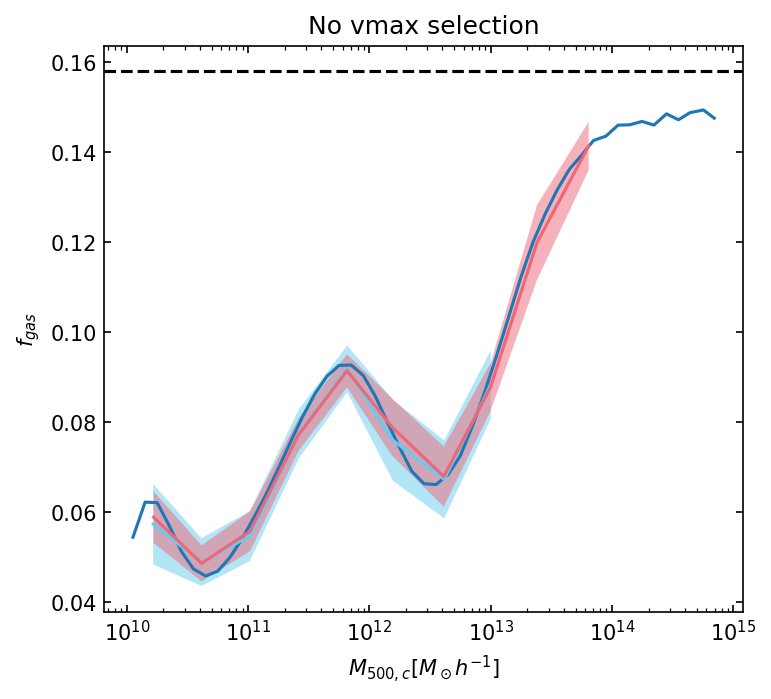

In [898]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')

ax.plot(fgas_total['m500'], fgas_total['f_gas'])
ax.plot(mean_m500['2'], mean_fgas['2'], color=colors[1])
ax.plot(mean_m500['4'], mean_fgas['4'], color=colors[4])

ax.fill_between(mean_m500['2'], mean_fgas['2']-err_fgas['2'], mean_fgas['2']+err_fgas['2'], color=colors[1], alpha=0.5, edgecolor=None)
ax.fill_between(mean_m500['4'], mean_fgas['4']-err_fgas['4'], mean_fgas['4']+err_fgas['4'], color=colors[4], alpha=0.5, edgecolor=None)
    
ax.axhline(0.158, color='k', ls='--')

ax.set_title('No vmax selection')

ax.set_ylabel('$f_{gas}$')
ax.set_xlabel('$M_{500,c}[M_\\odot h^{-1}]$')

Text(0.5, 0, '$M_{500,c}[M_\\odot h^{-1}]$')

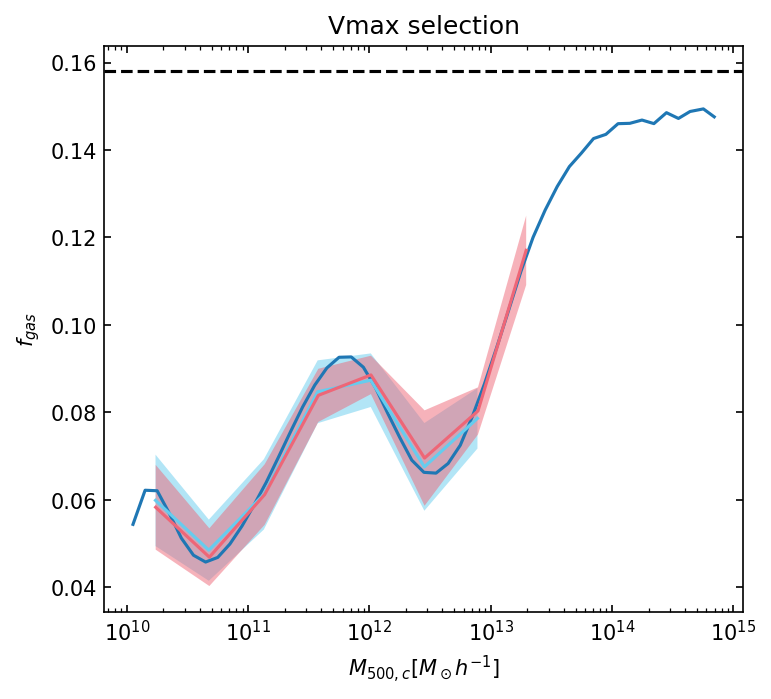

In [899]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')

ax.plot(fgas_total['m500'], fgas_total['f_gas'])
ax.plot(mean_m500_vmax['2'], mean_fgas_vmax['2'], color=colors[1])
ax.plot(mean_m500_vmax['4'], mean_fgas_vmax['4'], color=colors[4])

ax.fill_between(mean_m500_vmax['2'], mean_fgas_vmax['2']-err_fgas_vmax['2'], mean_fgas_vmax['2']+err_fgas_vmax['2'], color=colors[1], alpha=0.5, edgecolor=None)
ax.fill_between(mean_m500_vmax['4'], mean_fgas_vmax['4']-err_fgas_vmax['4'], mean_fgas_vmax['4']+err_fgas_vmax['4'], color=colors[4], alpha=0.5, edgecolor=None)
    
ax.axhline(0.158, color='k', ls='--')

ax.set_title('Vmax selection')

ax.set_ylabel('$f_{gas}$')
ax.set_xlabel('$M_{500,c}[M_\\odot h^{-1}]$')

In [945]:
sfr_mstar = {}

sfr_mstar['2'] = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel['2'], vmax_sel=False, draws=100, nbins=20)
sfr_mstar['4'] = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel['4'], vmax_sel=False, draws=100, nbins=20)

/lscratch/fgmaion/MTNG-resims/src/utils.py:304: RuntimeWarning: invalid value encountered in divide
  sfr   = np.array(sfr)
/lscratch/fgmaion/MTNG-resims/src/utils.py:304: RuntimeWarning: divide by zero encountered in divide
  sfr   = np.array(sfr)
/lscratch/fgmaion/MTNG-resims/src/utils.py:316: RuntimeWarning: invalid value encountered in divide
  for d in range(draws):
/lscratch/fgmaion/MTNG-resims/src/utils.py:317: RuntimeWarning: invalid value encountered in divide
  sfr_mean[d] /= weights[d]


In [976]:
nbins=20

ens_sSFR = {}
ens_sSFR['2'] = np.zeros((100, nbins-1))
ens_sSFR['4'] = np.zeros((100, nbins-1))

ens_mstar = {}
ens_mstar['2'] = np.zeros((100, nbins-1))
ens_mstar['4'] = np.zeros((100, nbins-1))

temp_2 = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel['2'], vmax_sel=False, draws=100, nbins=nbins)
temp_4 = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel['4'], vmax_sel=False, draws=100, nbins=nbins)

for i in range(100):
    ens_sSFR['2'][i] = temp_2['sSFR'][i]
    ens_mstar['2'][i] = temp_2['mstar'][i]
    ens_mstar['2'][i][np.where(np.isnan(ens_mstar['2'][i]))] = 0

    ens_sSFR['4'][i] = temp_4['sSFR'][i]
    ens_mstar['4'][i] = temp_4['mstar'][i]
    ens_mstar['4'][i][np.where(np.isnan(ens_mstar['4'][i]))] = 0


[autoreload of utils failed: Traceback (most recent call last):
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 257, in check
    superreload(m, reload, self.old_objects)
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 455, in superreload
    module = reload(module)
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 613, in _exec
  File "<frozen importlib._bootstrap_external>", line 846, in exec_module
  File "<frozen importlib._bootstrap_external>", line 983, in get_code
  File "<frozen importlib._bootstrap_external>", line 913, in source_to_code
  File "<frozen importlib._bootstrap>", line 228, in _call_with_frames_removed
  File "/lscratch/fgmaion/MTNG-resims/src/utils.py", line 348
    sSFR   = np.array(1e1

In [977]:
ens_sSFR_vmax = {}
ens_sSFR_vmax['2'] = np.zeros((100, nbins-1))
ens_sSFR_vmax['4'] = np.zeros((100, nbins-1))

ens_mstar_vmax = {}
ens_mstar_vmax['2'] = np.zeros((100, nbins-1))
ens_mstar_vmax['4'] = np.zeros((100, nbins-1))

temp_4 = hydro_split.halo_SFR(sel_mask=ens_sel_vmax['4'], nbins=nbins, mhalo_edges=mass_edges, vmax_sel=True, draws=100)
temp_2 = hydro_split.halo_SFR(sel_mask=ens_sel_vmax['2'], nbins=nbins, mhalo_edges=mass_edges, vmax_sel=True, draws=100)

for i in range(100):
    ens_sSFR_vmax['2'][i] = temp_2['sSFR'][i]
    ens_mstar_vmax['2'][i] = temp_2['mstar'][i]
    ens_mstar_vmax['2'][i][np.where(np.isnan(ens_mstar_vmax['2'][i]))] = 0

    ens_sSFR_vmax['4'][i] = temp_4['sSFR'][i]
    ens_mstar_vmax['4'][i] = temp_4['mstar'][i]
    ens_mstar_vmax['4'][i][np.where(np.isnan(ens_mstar_vmax['4'][i]))] = 0


/lscratch/fgmaion/MTNG-resims/src/utils.py:302: RuntimeWarning: invalid value encountered in divide
  sSFR  = np.array(1e10 * sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:302: RuntimeWarning: divide by zero encountered in divide
  sSFR  = np.array(1e10 * sSFR) / mstar


In [978]:
mean_sSFR = {}
mean_sSFR['2'] = np.mean(ens_sSFR['2'], axis=0)
mean_sSFR['4'] = np.mean(ens_sSFR['4'], axis=0)

mean_mstar = {}
mean_mstar['2'] = np.mean(ens_mstar['2'], axis=0)
mean_mstar['4'] = np.mean(ens_mstar['4'], axis=0)

err_sSFR = {}
err_sSFR['2'] = np.std(ens_sSFR['2'], axis=0)
err_sSFR['4'] = np.std(ens_sSFR['4'], axis=0)

In [979]:
mean_sSFR_vmax = {}
mean_sSFR_vmax['2'] = np.mean(ens_sSFR_vmax['2'], axis=0)
mean_sSFR_vmax['4'] = np.mean(ens_sSFR_vmax['4'], axis=0)

mean_mstar_vmax = {}
mean_mstar_vmax['2'] = np.mean(ens_mstar_vmax['2'], axis=0)
mean_mstar_vmax['4'] = np.mean(ens_mstar_vmax['4'], axis=0)

err_sSFR_vmax = {}
err_sSFR_vmax['2'] = np.std(ens_sSFR_vmax['2'], axis=0)
err_sSFR_vmax['4'] = np.std(ens_sSFR_vmax['4'], axis=0)

In [983]:
sSFR_total = hydro_split.total_SFR(nbins=nbins)

/lscratch/fgmaion/MTNG-resims/src/utils.py:348: RuntimeWarning: divide by zero encountered in divide
  sSFR   = np.array(1e10 * self.sim.sub['SFR']) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:348: RuntimeWarning: invalid value encountered in divide
  sSFR   = np.array(1e10 * self.sim.sub['SFR']) / mstar


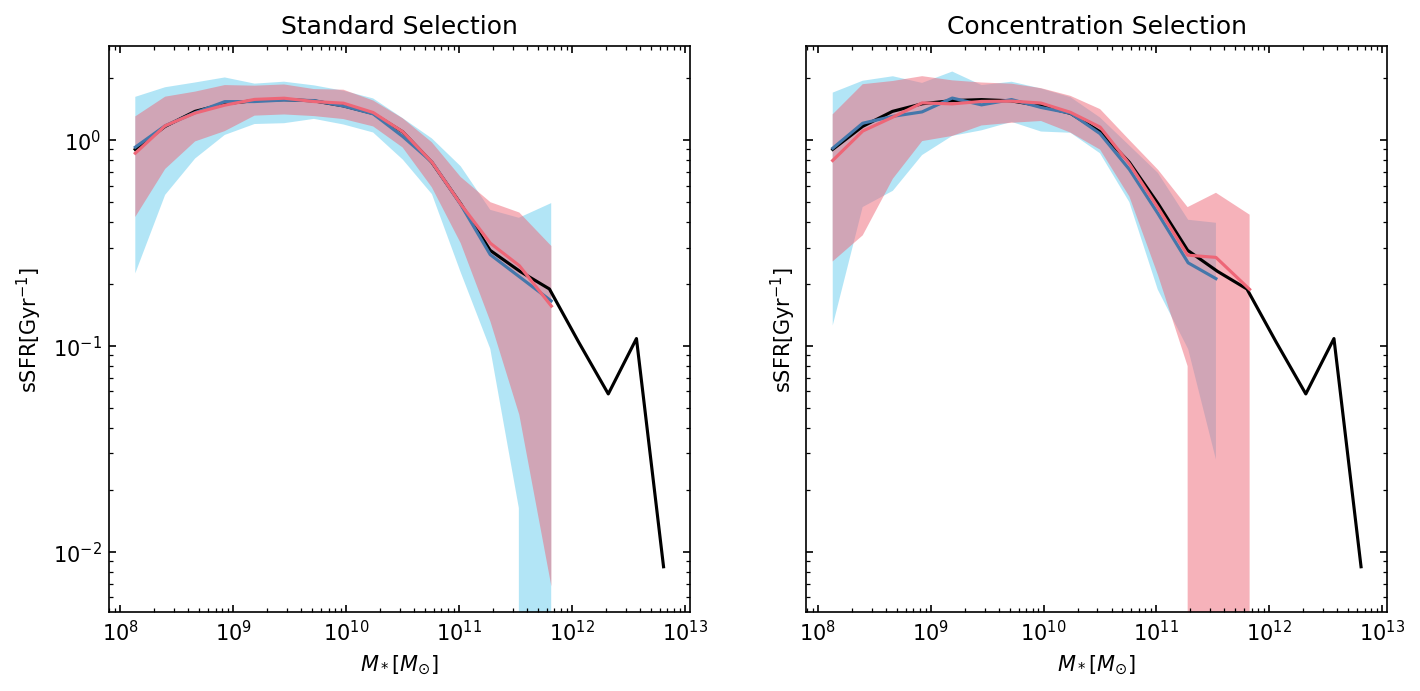

In [989]:
fig, ax = plt.subplots(1, 2, dpi=150, figsize=(11,5), sharey=True)

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[0].set_ylabel('sSFR[Gyr$^{-1}$]')
ax[0].set_xlabel('$M_*[M_{\\odot}]$')

ax[0].set_title('Standard Selection')

ax[0].plot(sSFR_total['mstar'], sSFR_total['sSFR'], color='k')
ax[0].plot(mean_mstar['2'], mean_sSFR['2'], color=colors[0])
ax[0].plot(mean_mstar['4'], mean_sSFR['4'], color=colors[4])

ax[0].fill_between(mean_mstar['2'], mean_sSFR['2']-err_sSFR['2'], mean_sSFR['2']+err_sSFR['2'], color=colors[1], alpha=0.5, edgecolor=None)
ax[0].fill_between(mean_mstar['4'], mean_sSFR['4']-err_sSFR['4'], mean_sSFR['4']+err_sSFR['4'], color=colors[4], alpha=0.5, edgecolor=None)

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[1].set_title('Concentration Selection')

ax[1].set_ylabel('sSFR[Gyr$^{-1}$]')
ax[1].set_xlabel('$M_*[M_{\\odot}]$')

ax[1].plot(sSFR_total['mstar'], sSFR_total['sSFR'], color='k')
ax[1].plot(mean_mstar_vmax['2'], mean_sSFR_vmax['2'], color=colors[0])
ax[1].plot(mean_mstar_vmax['4'], mean_sSFR_vmax['4'], color=colors[4])

ax[1].fill_between(mean_mstar_vmax['2'], mean_sSFR_vmax['2']-err_sSFR_vmax['2'], mean_sSFR_vmax['2']+err_sSFR_vmax['2'], color=colors[1], alpha=0.5, edgecolor=None)
ax[1].fill_between(mean_mstar_vmax['4'], mean_sSFR_vmax['4']-err_sSFR_vmax['4'], mean_sSFR_vmax['4']+err_sSFR_vmax['4'], color=colors[4], alpha=0.5, edgecolor=None)

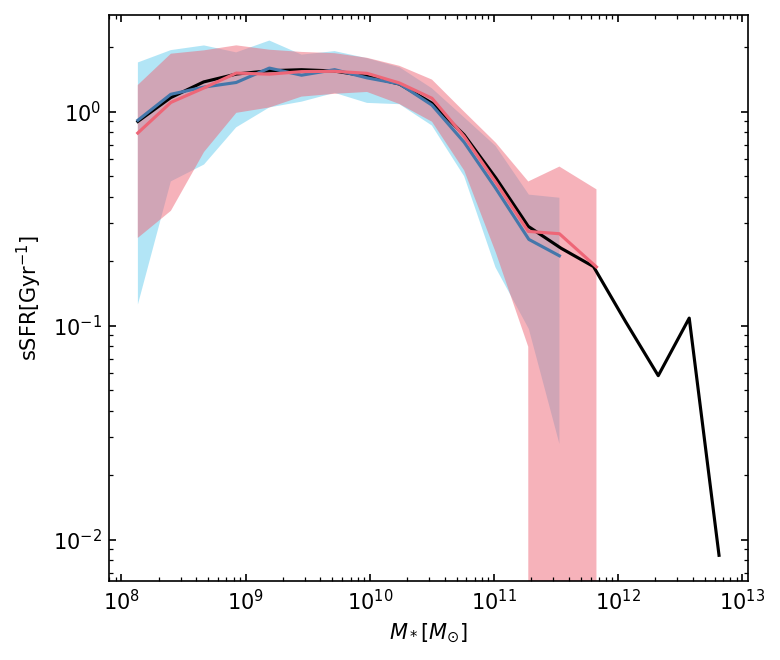

In [985]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel('sSFR[Gyr$^{-1}$]')
ax.set_xlabel('$M_*[M_{\\odot}]$')

ax.plot(sSFR_total['mstar'], sSFR_total['sSFR'], color='k')
ax.plot(mean_mstar_vmax['2'], mean_sSFR_vmax['2'], color=colors[0])
ax.plot(mean_mstar_vmax['4'], mean_sSFR_vmax['4'], color=colors[4])

ax.fill_between(mean_mstar_vmax['2'], mean_sSFR_vmax['2']-err_sSFR_vmax['2'], mean_sSFR_vmax['2']+err_sSFR_vmax['2'], color=colors[1], alpha=0.5, edgecolor=None)
ax.fill_between(mean_mstar_vmax['4'], mean_sSFR_vmax['4']-err_sSFR_vmax['4'], mean_sSFR_vmax['4']+err_sSFR_vmax['4'], color=colors[4], alpha=0.5, edgecolor=None)
